**Description:**

This notebook develops and compares machine learning regression models to predict fair launch success metrics. It includes:

- Ridge Regression: A linear baseline model with L2 regularization
- Random Forest: A tree-based ensemble model for capturing non-linear patterns
- XGBoost: A gradient boosting model with hyperparameter tuning

The notebook evaluates each model using metrics like RMSE, MAE, and R², and analyzes feature importance to determine which variables drive success in LBP (Liquidity Bootstrapping Pool) fair launches. It's designed to identify which features matter most and find the best-performing predictive model for the fair-launch-analytics project.

# Imports

In [ ]:
%pip install scikit-learn xgboost

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.utils import resample
from sklearn.inspection import partial_dependence

import xgboost as xgb

# Stratified split and scaling

In [34]:
# 1. PREPARE FEATURES (X) AND TARGET (y)

X_train = pd.read_csv('../media/ML/X_train.csv')
X_test = pd.read_csv('../media/ML/X_test.csv')
y_train = pd.read_csv('../media/ML/y_train.csv').squeeze()  # Convert to Series
y_test = pd.read_csv('../media/ML/y_test.csv').squeeze()    # Convert to Series

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("\nColumns in X_train:", X_train.columns.tolist())


def evaluate_model(y_true, y_pred, y_prob):
    print("F1 Score (Macro):", f1_score(y_true, y_pred, average='macro'))
    print("ROC-AUC Score:", roc_auc_score(y_true, y_prob))
    # 'macro' average is useful here to treat both classes as important

Training features shape: (768, 13)
Testing features shape: (193, 13)
Training target shape: (768,)
Testing target shape: (193,)

Columns in X_train: ['duration_hours', 'start_weight_proj', 'end_weight_proj', 'weight_slope', 'swap_fee_pct', 'collateral_is_stable', 'is_weekend', 'weekend_pct', 'chain_arbitrum', 'chain_base', 'chain_ethereum', 'chain_optimism', 'chain_polygon']


# Training

## Logistic regression

--- BASELINE (DUMMY) PERFORMANCE ---
   RMSE (Lower is better): 0.2159
   MAE  (Lower is better): 0.1793
   R²   (Higher is better): -0.0141
   (R²=0.0 means the model is just guessing the average)


--- RIDGE REGRESSION PERFORMANCE ---
   RMSE (Lower is better): 0.2155
   MAE  (Lower is better): 0.1773
   R²   (Higher is better): -0.0110
   (R²=0.0 means the model is just guessing the average)


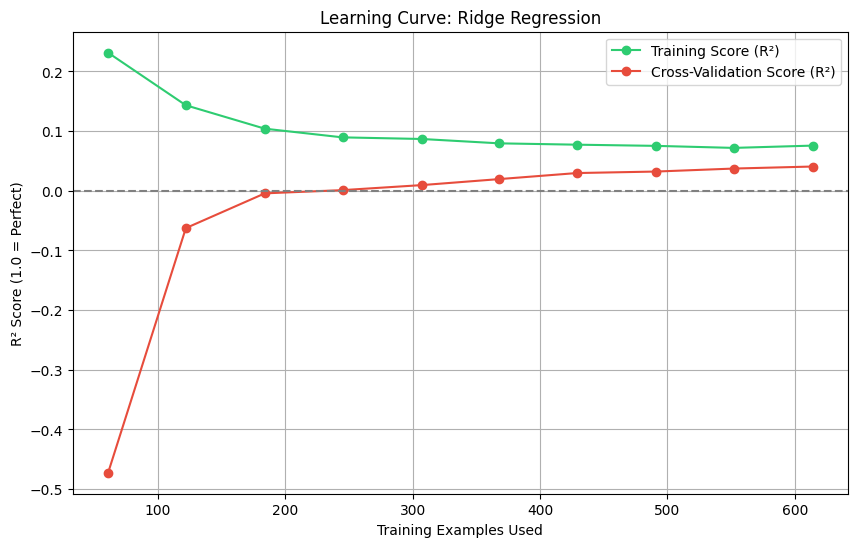

In [7]:
# ==============================================================================
# HELPER: REGRESSION EVALUATION
# ==============================================================================
def evaluate_regression(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} PERFORMANCE ---")
    print(f"   RMSE (Lower is better): {rmse:.4f}")
    print(f"   MAE  (Lower is better): {mae:.4f}")
    print(f"   R²   (Higher is better): {r2:.4f}")
    print(f"   (R²=0.0 means the model is just guessing the average)")

# ---------------------------------------------------------
# STEP 5 (Part A): ESTABLISH THE DUMMY BASELINE
# ---------------------------------------------------------
# Why: If our complex model can't beat this, it's useless.
# This "stupid" model just guesses the MEAN success score every time.

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

evaluate_regression(y_test, y_pred_dummy, "BASELINE (DUMMY)")
print("\n")

# ---------------------------------------------------------
# STEP 4 & 5 (Part B): TRAIN RIDGE REGRESSION
# ---------------------------------------------------------
# We use Ridge (Linear Regression + L2 Regularization) 
# because it handles small datasets (N=961) better than simple LinearRegression.

model = Ridge(alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Predictions (Continuous Float values)
y_pred = model.predict(X_test)

evaluate_regression(y_test, y_pred, "RIDGE REGRESSION")

# ---------------------------------------------------------
# VISUALIZATION: LEARNING CURVE
# ---------------------------------------------------------
# This answers: "Is my model learning? Would more data help?"
# We use 'r2' (Coefficient of Determination) as the score.

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train, cv=5, scoring='r2',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calculate means for plotting
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#2ecc71", label="Training Score (R²)")
plt.plot(train_sizes, test_mean, 'o-', color="#e74c3c", label="Cross-Validation Score (R²)")

plt.title("Learning Curve: Ridge Regression")
plt.xlabel("Training Examples Used")
plt.ylabel("R² Score (1.0 = Perfect)")
plt.legend(loc="best")
plt.grid(True)
plt.axhline(y=0, color='gray', linestyle='--', label='Baseline (Mean)')
plt.show()

**Conclusion:**

- Model is too simple. It cannot capture the pattern even in the training data (Green line dropped essentially to random chance).
- Model is technically "worse" than doing nothing. This happens because class_weight='balanced' forces the model to guess "Success" more often. Since the model isn't smart yet, it makes many False Positives, dragging the score down.

## Random Forest

⏳ Training Random Forest...
--- RANDOM FOREST PERFORMANCE ---
   RMSE (Lower is better): 0.2090
   MAE  (Lower is better): 0.1692
   R²   (Higher is better): 0.0492
   (R²=0.0 means the model is just guessing the average)


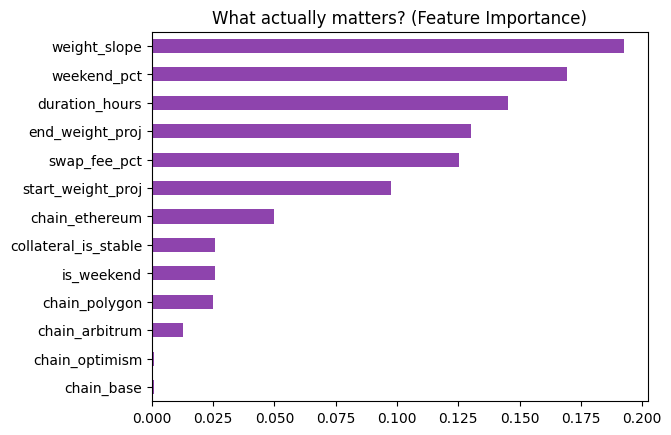

In [9]:
print("⏳ Training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=200,      # Number of trees
    max_depth=10,          # Prevent overfitting
    min_samples_split=5,   # Regularization
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evaluate_regression(y_test, y_pred_rf, "RANDOM FOREST")

# ---------------------------------------------------------
# FEATURE IMPORTANCE (The Truth Serum)
# ---------------------------------------------------------
# If RF fails too, then the data truly has no signal.
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).plot(kind='barh', color='#8e44ad')
plt.title("What actually matters? (Feature Importance)")
plt.show()

## XGBoost

⏳ Starting Randomized Hyperparameter Search (This may take a minute)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Best Params Found: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

--- XGBOOST FINAL RESULTS ---
   RMSE (Lower is better): 0.2083
   MAE  (Lower is better): 0.1716
   R²   (Higher is better): 0.0558


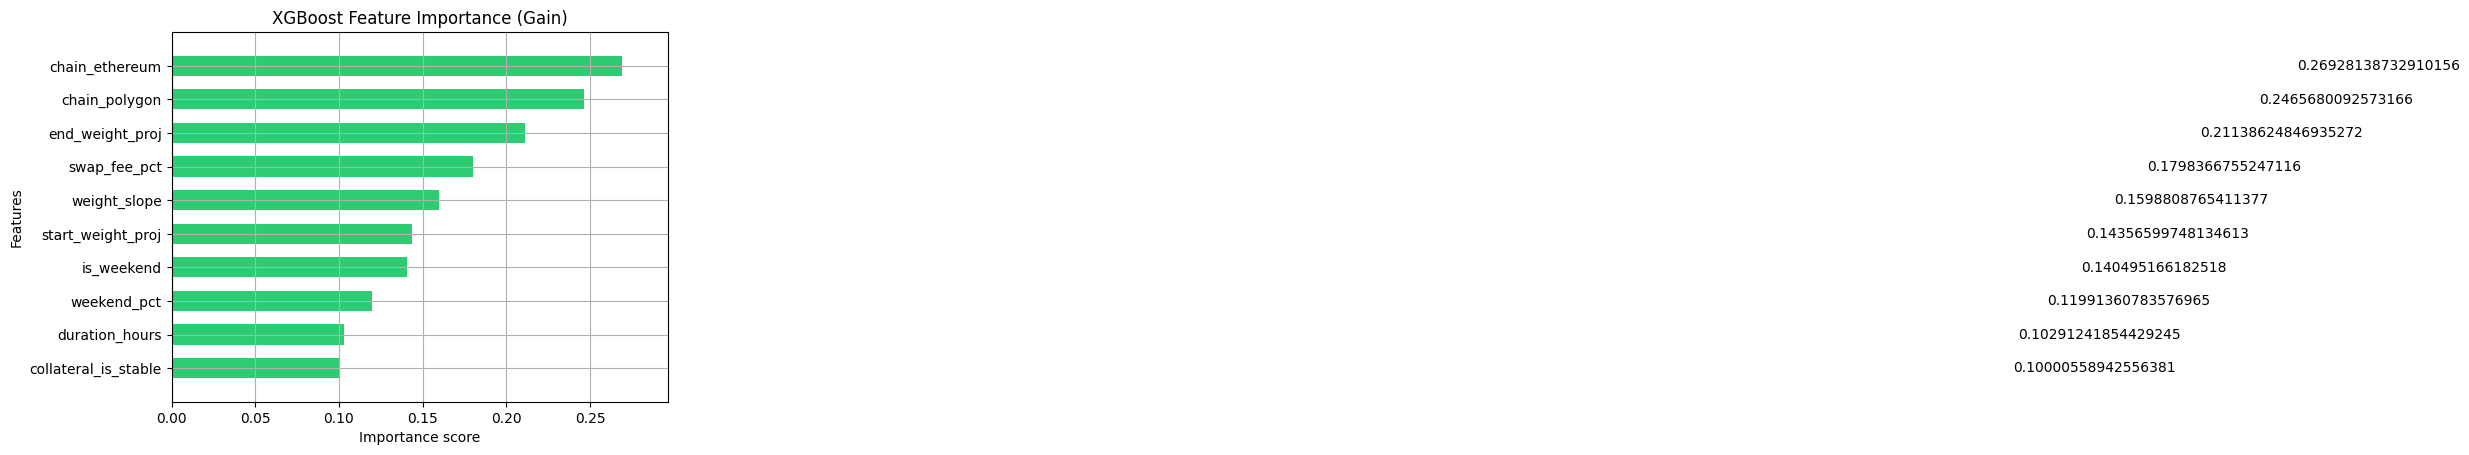

In [35]:
def train_xgboost():
    
    # ==========================================================================
    # 1. DEFINE HYPERPARAMETER GRID
    # ==========================================================================
    # XGBoost needs tuning. We test random combinations of these settings.
    param_grid = {
        'n_estimators': [100, 300, 500],        # Number of boosting rounds
        'learning_rate': [0.01, 0.05, 0.1],     # How much each tree corrects errors
        'max_depth': [3, 5, 7],                 # Tree depth (prevent overfitting)
        'subsample': [0.7, 0.8, 0.9],           # Use only % of rows per tree
        'colsample_bytree': [0.7, 0.8, 1.0],    # Use only % of columns per tree
        'reg_alpha': [0, 0.1, 0.5],             # L1 Regularization
        'reg_lambda': [1, 1.5, 2]               # L2 Regularization
    }
    
    print("⏳ Starting Randomized Hyperparameter Search (This may take a minute)...")
    
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
    
    # Try 50 random combinations
    search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_grid,
        n_iter=50,
        scoring='r2',
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    
    # ==========================================================================
    # 2. EVALUATE BEST MODEL
    # ==========================================================================
    best_model = search.best_estimator_
    print(f"\n✅ Best Params Found: {search.best_params_}")
    
    y_pred = best_model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("\n--- XGBOOST FINAL RESULTS ---")
    print(f"   RMSE (Lower is better): {rmse:.4f}")
    print(f"   MAE  (Lower is better): {mae:.4f}")
    print(f"   R²   (Higher is better): {r2:.4f}")

    # ==========================================================================
    # 3. FEATURE IMPORTANCE PLOT
    # ==========================================================================
    # XGBoost calculates importance differently (Gain = Improvement in accuracy)
    xgb.plot_importance(best_model, importance_type='gain', max_num_features=10, height=0.6, color='#2ecc71')
    plt.title('XGBoost Feature Importance (Gain)')
    plt.show()

if __name__ == "__main__":
    train_xgboost()

# Moving from prediction to optimization

🔄 Retraining RF on Unscaled Data for Interpretability...
📊 Generating Sweet Spot Analysis...


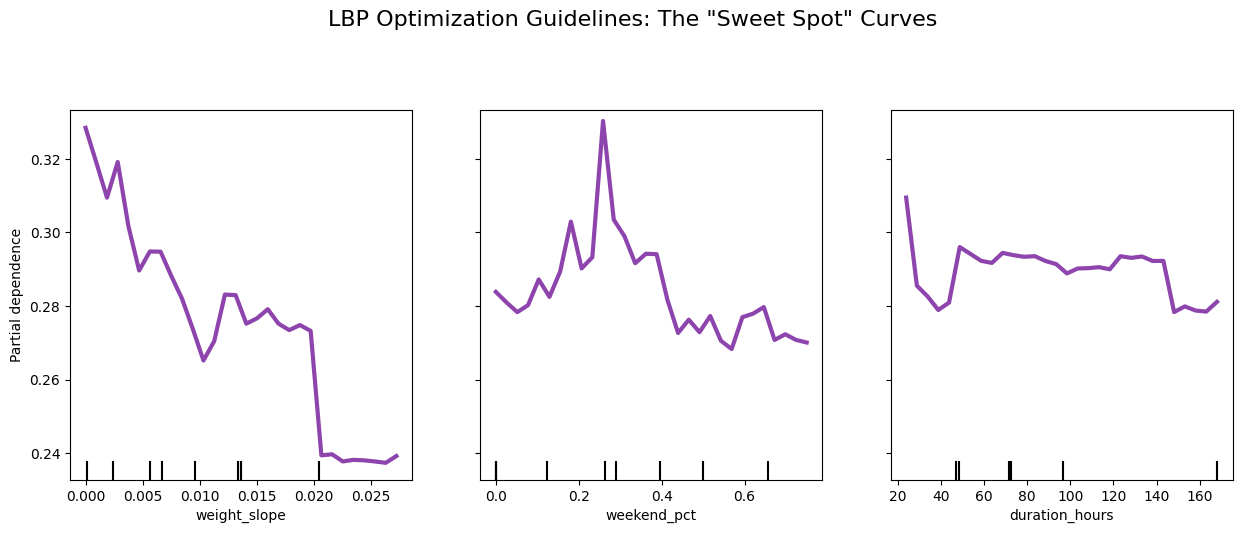

In [29]:
INPUT_FILE = "../media/ML/training_dataset.csv"  # The raw merged file (Unscaled)

# ==============================================================================
# 1. PREPARE DATA (UNSCALED)
# ==============================================================================
def load_unscaled_data():
    df = pd.read_csv(INPUT_FILE)
    
    # Drop redundant columns (Reserve weights)
    cols_to_drop = ['start_weight_reserve', 'end_weight_reserve', 'pool_address']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    # Cap outliers (just to keep graphs clean)
    # We clip Duration at 168h (1 week) because rarely LBPs go longer
    if 'duration_hours' in df.columns:
        df['duration_hours'] = np.clip(df['duration_hours'], 12, 168)
        
    # One-Hot Encode Chain
    df = pd.get_dummies(df, columns=['chain'], prefix='chain', dtype=int)
    
    # Split X and y
    target_col = 'final_success_score'
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    return X, y

# ==============================================================================
# 2. GENERATE PARTIAL DEPENDENCE PLOTS
# ==============================================================================
def plot_sweet_spots():
    print("🔄 Retraining RF on Unscaled Data for Interpretability...")
    X, y = load_unscaled_data()
    
    # Train RF (Same parameters as before)
    model = RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_split=5, 
        random_state=42, n_jobs=-1
    )
    model.fit(X, y)
    
    print("📊 Generating Sweet Spot Analysis...")
    
    # Features to Analyze (The Top 3 from your Importance Plot)
    features_to_plot = [
        'weight_slope',  # Velocity
        'weekend_pct',   # Timing
        'duration_hours' # Time Window
    ]
    
    # Create the Plot
    fig, ax = plt.subplots(figsize=(15, 5))
    display = PartialDependenceDisplay.from_estimator(
        model, 
        X, 
        features_to_plot,
        kind="average", # Shows the trend
        n_jobs=-1, 
        grid_resolution=30,
        ax=ax,
        line_kw={"color": "#8e44ad", "linewidth": 3}
    )
    
    # Formatting
    fig.suptitle('LBP Optimization Guidelines: The "Sweet Spot" Curves', fontsize=16, y=1.05)
    plt.subplots_adjust(top=0.85)
    plt.show()

if __name__ == "__main__":
    plot_sweet_spots()

## Stability test

🔄 Training 20 Bootstrap Models & Computing Curves...


/home/kaique/Documents/Projetos/fair-launch-analytics/venv/lib64/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 'is_weekend' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/home/kaique/Documents/Projetos/fair-launch-analytics/venv/lib64/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 'chain_arbitrum' contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-

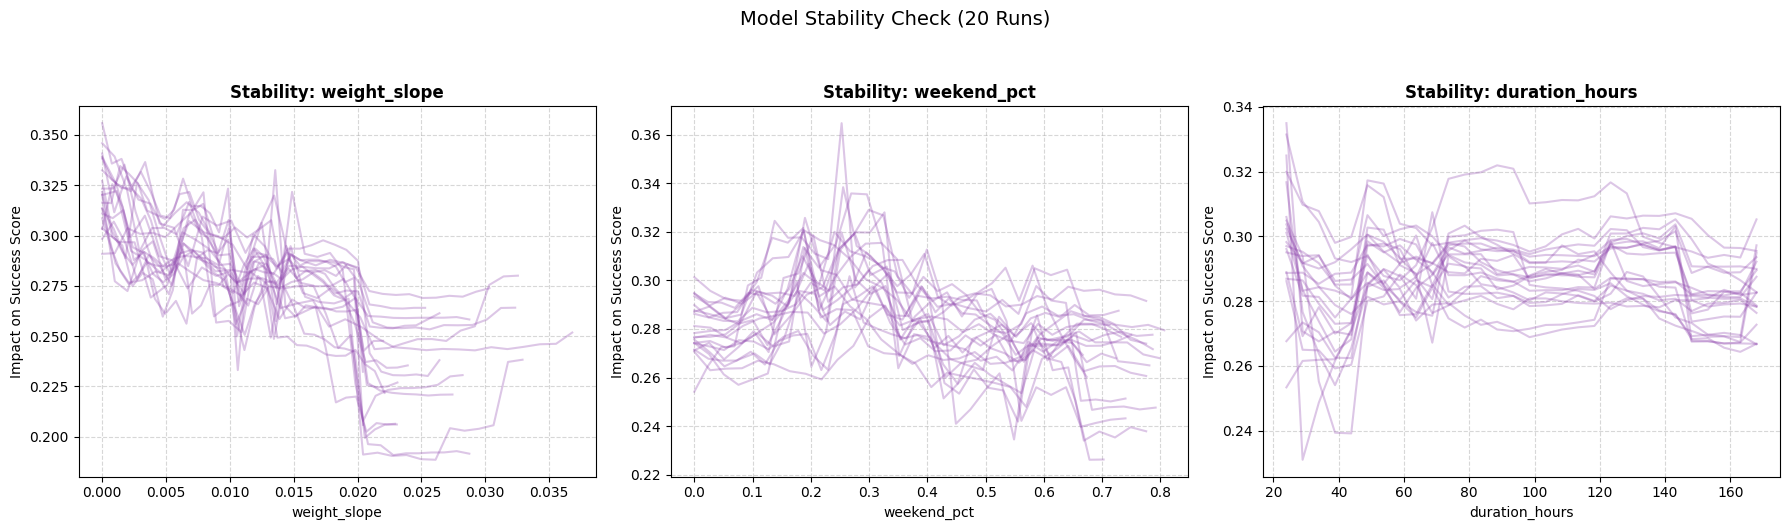


FEATURE                   | IMPACT     | NOISE      | STABILITY 
chain_ethereum            | 0.0701     | 0.0139     | 80.1% ⭐
weight_slope              | 0.0835     | 0.0200     | 76.0% ⭐
swap_fee_pct              | 0.0518     | 0.0176     | 65.9% 
end_weight_proj           | 0.0433     | 0.0153     | 64.7% 
weekend_pct               | 0.0397     | 0.0144     | 63.8% 
duration_hours            | 0.0261     | 0.0108     | 58.9% 
start_weight_proj         | 0.0316     | 0.0152     | 51.8% 
chain_polygon             | 0.0256     | 0.0138     | 46.0% 
is_weekend                | 0.0123     | 0.0086     | 30.5% 
collateral_is_stable      | 0.0033     | 0.0078     | 0.0% 
chain_arbitrum            | 0.0001     | 0.0070     | 0.0% 
chain_base                | 0.0016     | 0.0068     | 0.0% 
chain_optimism            | 0.0004     | 0.0070     | 0.0% 
⭐ = Prime Candidate for Optimization Guidelines


In [31]:
N_BOOTSTRAPS = 20
FEATURES_TO_PLOT = ['weight_slope', 'weekend_pct', 'duration_hours']

def load_data():
    df = pd.read_csv(INPUT_FILE)
    
    # Standard Cleaning
    cols_to_drop = ['start_weight_reserve', 'end_weight_reserve', 'pool_address']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    if 'duration_hours' in df.columns:
        df['duration_hours'] = np.clip(df['duration_hours'], 12, 168)
        
    # One-Hot Encode Chain
    df = pd.get_dummies(df, columns=['chain'], prefix='chain', dtype=int)
    
    target_col = 'final_success_score'
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    return X, y


def run_bootstrap_analysis(X, y):
    """
    Trains models and computes PDP curves ONCE.
    Returns a dictionary: {feature_name: [{'x': grid, 'y': curve}, ...]}
    """
    print(f"🔄 Training {N_BOOTSTRAPS} Bootstrap Models & Computing Curves...")
    
    features = X.columns.tolist()
    results = {f: [] for f in features}
    
    for i in range(N_BOOTSTRAPS):
        # 1. Resample (Simulate different datasets)
        X_boot, y_boot = resample(X, y, random_state=i, replace=True)
        
        # 2. Train Model (Only happens here)
        model = RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1)
        model.fit(X_boot, y_boot)
        
        # 3. Compute PDP for ALL features immediately
        # This saves us from ever having to retrain or re-predict later
        for feat in features:
            pd_res = partial_dependence(model, X_boot, [feat], kind='average', grid_resolution=30)
            
            results[feat].append({
                'x': pd_res['grid_values'][0], # X-axis (e.g., Duration 12h-168h)
                'y': pd_res['average'][0]      # Y-axis (Impact on Score)
            })
            
    return results

def plot_stability(results):
    # Setup plot for selected features
    valid_feats = [f for f in FEATURES_TO_PLOT if f in results]
    if not valid_feats: return

    fig, axes = plt.subplots(1, len(valid_feats), figsize=(6 * len(valid_feats), 5))
    if len(valid_feats) == 1: axes = [axes] # Handle single plot case

    for j, feature in enumerate(valid_feats):
        # Plot every bootstrap line to show spread
        for run_data in results[feature]:
            axes[j].plot(run_data['x'], run_data['y'], color='#8e44ad', alpha=0.3, linewidth=1.5)

        axes[j].set_title(f"Stability: {feature}", fontsize=12, fontweight='bold')
        axes[j].set_xlabel(feature)
        axes[j].set_ylabel("Impact on Success Score")
        axes[j].grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(f'Model Stability Check ({N_BOOTSTRAPS} Runs)', y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()

def print_metrics(results):
    print("\n" + "="*70)
    print(f"{'FEATURE':<25} | {'IMPACT':<10} | {'NOISE':<10} | {'STABILITY':<10}")
    print("="*70)

    # Sort results by Stability for better readability
    metrics_data = []

    for feat, runs in results.items():
        # Extract just the Y curves into a matrix
        curves_matrix = np.array([r['y'] for r in runs])
        
        # Calculate Signal (Mean Curve Amplitude)
        mean_curve = np.mean(curves_matrix, axis=0)
        impact = np.max(mean_curve) - np.min(mean_curve)
        
        # Calculate Noise (Avg Std Dev across runs)
        std_curve = np.std(curves_matrix, axis=0)
        avg_noise = np.mean(std_curve)
        
        # Stability Score
        if impact < 0.001: 
            stability = 0.0
        else:
            stability = max(0, 1 - (avg_noise / impact))
            
        metrics_data.append((feat, impact, avg_noise, stability))

    # Sort by Stability (Descending)
    metrics_data.sort(key=lambda x: x[3], reverse=True)

    for feat, impact, noise, stability in metrics_data:
        mark = "⭐" if stability > 0.70 else ""
        print(f"{feat:<25} | {impact:.4f}     | {noise:.4f}     | {stability:.1%} {mark}")

    print("="*70)
    print("⭐ = Prime Candidate for Optimization Guidelines")

if __name__ == "__main__":
    # 1. Load
    X, y = load_data()
    
    # 2. Process (Train Once)
    results_cache = run_bootstrap_analysis(X, y)
    
    # 3. Output (Read Cache)
    plot_stability(results_cache)
    print_metrics(results_cache)